In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import heapq

from mazemods import maze
from mazemods import makeMaze
from mazemods import collisionCheck
from mazemods import makePath
from mazemods import getPathFromActions
from mazemods import getCostOfActions
from mazemods import stayWestCost
from mazemods import stayEastCost

import mediumMaze

In [69]:
n = mediumMaze.n
m = mediumMaze.m
O = mediumMaze.O

xI = (1,1)
xG = (30,16)
#xG = (10,10)
#xG = (9,9)

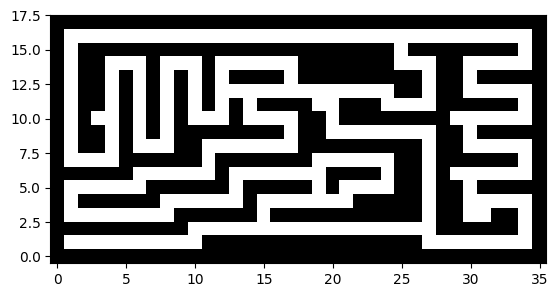

In [70]:
makeMaze(n,m,O)
maze(n,m,O)
plt.show()

In [71]:
def manhattanHeuristic(x, xG):
    return sum(abs(a - b) for a, b in zip(x, xG))
    
def euclideanHeuristic(x, xG):
    squared_diffs = sum((a - b) ** 2 for a, b in zip(x, xG))
    return squared_diffs ** 0.5

#different heuristic to test the function

def horizontalHeuristic(x, xG):
    return abs(x[1] - xG[1])
    
def verticalHeuristic(x, xG):
    return abs(x[0] - xG[0])

def badHeuristic(x, xG):
    return abs(x[0] + xG[0])

In [72]:
#testing the heuristics
md = manhattanHeuristic(xI, xG)
ed = euclideanHeuristic(xI, xG)
hd = horizontalHeuristic(xI, xG)
print(md)
print(ed)
print(hd)

44
32.64965543462902
15


In [73]:
def aStarSearch(xI,xG,n,m,O,heuristic):
    # Problem state parameters - xI: initial state, xG: goal state
    # Problem Environment Parameters - n: number of rows, m: number of columns, O: list of obstacles
    # Cost Function
    # Initializing the Q and visited set and creating parent map
    actions = [(1,0), (0,1), (-1,0), (0,-1)]
    Q = [(0, xI, [])] 
    visited_list = {xI}
    nodes_visited = 1

    while Q:
        predicted_cost, current_state, action_list = heapq.heappop(Q)
        if current_state == xG:
            path = getPathFromActions(xI, action_list)
            cost_path = getCostOfActions(xI,action_list,O) #regular cost - once we reach xG we just calculate it as usual
            path_to_plot = makePath(xI,xG,path,n,m,O)
            plt.imshow(path_to_plot)
            plt.gca().invert_yaxis()
            plt.show()
            #print(visited_list)
            print("The cost of the path is:", cost_path)
            print(nodes_visited," nodes were visited")
            return action_list, cost_path, nodes_visited
        else:
            for action in actions:
                next_state = (current_state[0] + action[0], current_state[1] + action[1])
                if next_state not in visited_list and not collisionCheck(current_state, action, O):
                    predicted_cost = getCostOfActions(xI,action_list,O) + heuristic(current_state, xG)
                    #print(predicted_cost)
                    Q.append((predicted_cost, next_state, action_list + [action]))
                    visited_list.add(next_state)
                    nodes_visited += 1
    if not Q:
        print("Could not find a path to goal")
        print("Current state:", current_state)
        print(nodes_visited, " nodes visited")
        #print("List of visited nodes", visited_list)
        #print("List of actions till this point", action_list)

    return action_list, None, nodes_visited

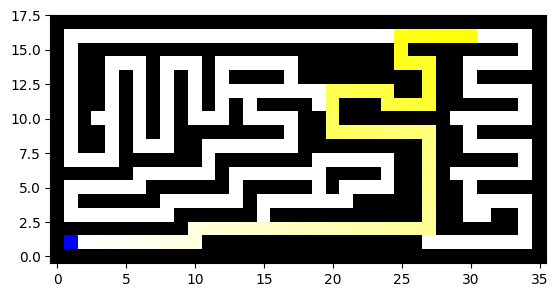

The cost of the path is: 64
152  nodes were visited


In [74]:
action_list, cost_path, nodes_visited = aStarSearch(xI,xG,n,m,O,heuristic = manhattanHeuristic)

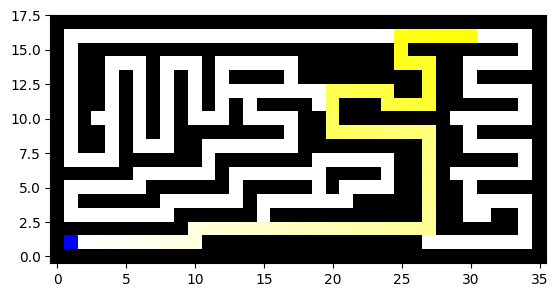

The cost of the path is: 64
158  nodes were visited


In [75]:
action_list, cost_path, nodes_visited = aStarSearch(xI,xG,n,m,O,heuristic = euclideanHeuristic)

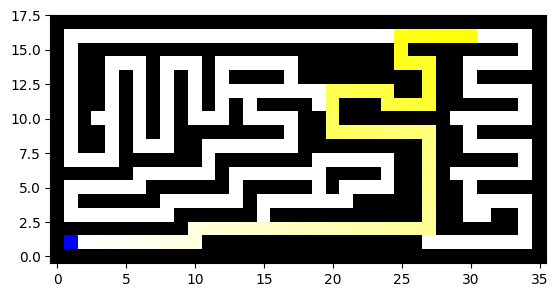

The cost of the path is: 64
195  nodes were visited


In [76]:
action_list, cost_path, nodes_visited = aStarSearch(xI,xG,n,m,O,heuristic = horizontalHeuristic)

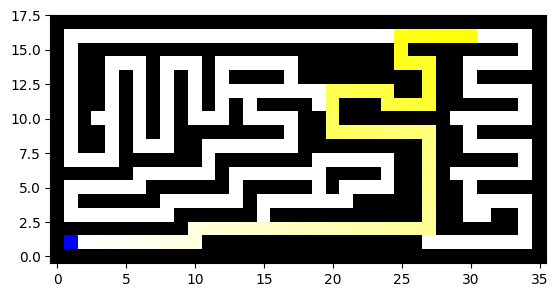

The cost of the path is: 64
163  nodes were visited


In [77]:
action_list, cost_path, nodes_visited = aStarSearch(xI,xG,n,m,O,heuristic = verticalHeuristic)

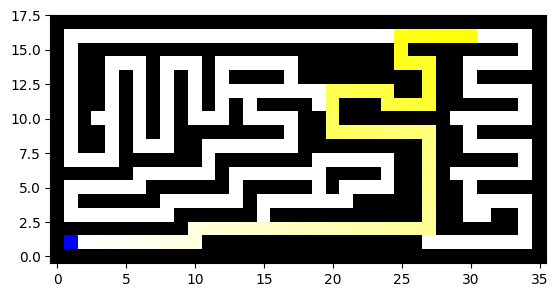

The cost of the path is: 64
257  nodes were visited


In [78]:
action_list, cost_path, nodes_visited = aStarSearch(xI,xG,n,m,O,heuristic = badHeuristic)